# Exp3


In [2]:
!pip install pandas requests


In [3]:
import requests
import pandas as pd
import time
import random
from datetime import datetime

dataset = []

def fetch_live_data():
    url = "https://openphish.com/feed.txt"
    response = requests.get(url)

    if response.status_code == 200:
        return response.text.split("\n")[:20]
    else:
        return []

print("Starting real-time data collection...")

for cycle in range(10):

    print(f"Cycle {cycle+1} collecting...")

    urls = fetch_live_data()

    for u in urls:
        if u.strip() == "":
            continue

        record = {
            "timestamp": datetime.now(),
            "source_ip": f"192.168.1.{random.randint(1,255)}",
            "request_length": len(u),
            "failed_login_attempts": random.randint(0,3),
            "api_request_frequency": random.randint(1,10),
            "geo_location": random.choice(["IN","US","UK","SG","DE"]),
            "resource_access_count": random.randint(1,20)
        }

        dataset.append(record)


    time.sleep(5)

print("Data collection completed.")


Starting real-time data collection...
Cycle 1 collecting...
Cycle 2 collecting...
Cycle 3 collecting...
Cycle 4 collecting...
Cycle 5 collecting...
Cycle 6 collecting...
Cycle 7 collecting...
Cycle 8 collecting...
Cycle 9 collecting...
Cycle 10 collecting...
Data collection completed.


In [4]:
df = pd.DataFrame(dataset)

print("Dataset Preview:")
print(df.head())

df.to_csv("cloud_security_realtime_logs.csv", index=False)

print("Dataset saved successfully!")


Dataset Preview:
                   timestamp      source_ip  request_length  \
0 2026-04-28 13:18:21.279077   192.168.1.98              59   
1 2026-04-28 13:18:21.279107   192.168.1.31              37   
2 2026-04-28 13:18:21.279119  192.168.1.147              38   
3 2026-04-28 13:18:21.279126  192.168.1.157              75   
4 2026-04-28 13:18:21.279134  192.168.1.199              34   

   failed_login_attempts  api_request_frequency geo_location  \
0                      0                     10           US   
1                      1                      8           DE   
2                      0                      3           UK   
3                      1                      3           US   
4                      3                      3           US   

   resource_access_count  
0                      1  
1                     12  
2                     19  
3                      8  
4                      5  
Dataset saved successfully!


In [5]:
df.drop_duplicates(inplace=True)

df.fillna(0, inplace=True)

df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Data cleaned.")


Data cleaned.


# Exp4


In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv("/content/cloud_security_realtime_logs.csv")

print(df.head())


                    timestamp      source_ip  request_length  \
0  2026-04-28 13:18:21.279077   192.168.1.98              59   
1  2026-04-28 13:18:21.279107   192.168.1.31              37   
2  2026-04-28 13:18:21.279119  192.168.1.147              38   
3  2026-04-28 13:18:21.279126  192.168.1.157              75   
4  2026-04-28 13:18:21.279134  192.168.1.199              34   

   failed_login_attempts  api_request_frequency geo_location  \
0                      0                     10           US   
1                      1                      8           DE   
2                      0                      3           UK   
3                      1                      3           US   
4                      3                      3           US   

   resource_access_count  
0                      1  
1                     12  
2                     19  
3                      8  
4                      5  


In [7]:
df.drop_duplicates(inplace=True)

df.fillna(0, inplace=True)

df['timestamp'] = pd.to_datetime(df['timestamp'])

print("After cleaning:", df.shape)

After cleaning: (200, 7)


In [8]:
features = [
    "request_length",
    "failed_login_attempts",
    "api_request_frequency",
    "resource_access_count",
]

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])


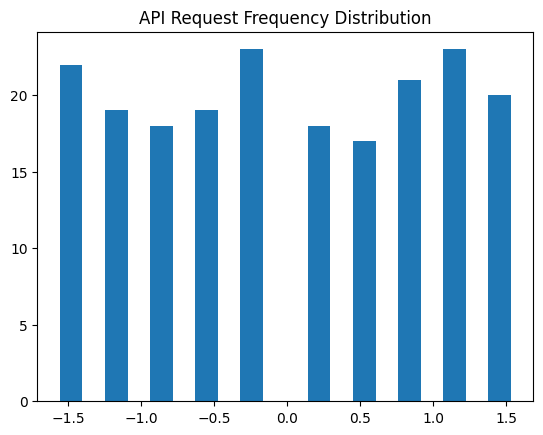

In [9]:
plt.hist(df["api_request_frequency"], bins=20)
plt.title("API Request Frequency Distribution")
plt.show()


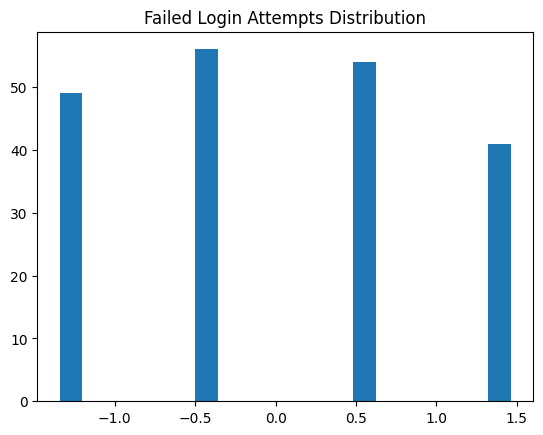

In [10]:
plt.hist(df["failed_login_attempts"], bins=20)
plt.title("Failed Login Attempts Distribution")
plt.show()


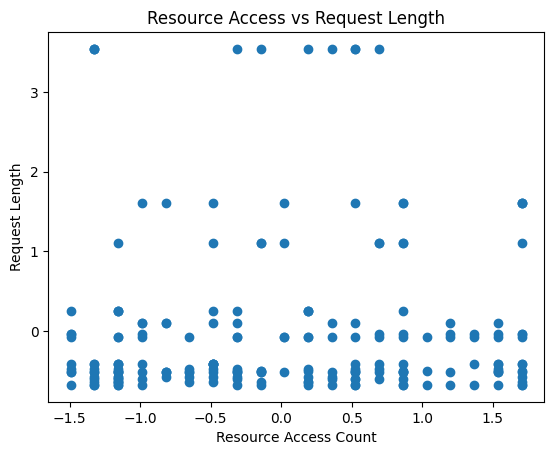

In [11]:
plt.scatter(df["resource_access_count"], df["request_length"])
plt.title("Resource Access vs Request Length")
plt.xlabel("Resource Access Count")
plt.ylabel("Request Length")
plt.show()


# Exp5


In [13]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("/content/cloud_security_realtime_logs.csv")

df['target'] = df.apply(
    lambda row: 1 if (row['failed_login_attempts'] > 2 or
                      row['api_request_frequency'] > 8) else 0,
    axis=1
)

df.drop(['timestamp', 'source_ip'], axis=1, inplace=True)

le = LabelEncoder()
df['geo_location'] = le.fit_transform(df['geo_location'])

X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

print("\n=== MODEL RESULTS ===\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-" * 50)

print("\n=== PERFORMANCE COMPARISON ===")
for model, acc in results.items():
    print(f"{model}: {acc}")

best_model = max(results, key=results.get)
print("\nBest Model:", best_model)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

tuned_model = grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))


=== MODEL RESULTS ===

Logistic Regression
Accuracy: 0.8
Confusion Matrix:
 [[18  3]
 [ 5 14]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82        21
           1       0.82      0.74      0.78        19

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40

--------------------------------------------------
Decision Tree
Accuracy: 1.0
Confusion Matrix:
 [[21  0]
 [ 0 19]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

--------------------------------------------------
Random Forest
Accuracy: 1.0
Confus